In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'NIH_ChestXray']


In [ ]:
import os

print(os.listdir('/content/drive/My Drive/NIH_ChestXray'))

['Data_Entry_2017.csv', 'train_val_list.txt', 'test_list.txt', 'images_001']


In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/NIH_ChestXray/Data_Entry_2017.csv')

print(df.shape)

df.head()

(112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [ ]:
df.columns

Index(['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID',
       'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width',
       'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11'],
      dtype='object')

In [ ]:
df["Finding Labels"].value_counts().head(20)

,count
Finding Labels,
No Finding,60361
Infiltration,9547
Atelectasis,4215
Effusion,3955
Nodule,2705
Pneumothorax,2194
Mass,2139
Effusion|Infiltration,1603
Atelectasis|Infiltration,1350


In [5]:
disease_labels = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

disease_labels

['Atelectasis',
 'Cardiomegaly',
 'Effusion',
 'Infiltration',
 'Mass',
 'Nodule',
 'Pneumonia',
 'Pneumothorax',
 'Consolidation',
 'Edema',
 'Emphysema',
 'Fibrosis',
 'Pleural_Thickening',
 'Hernia']

In [6]:
for disease in disease_labels:
    df[disease] = df["Finding Labels"].apply(lambda x: 1 if disease in x else 0)

df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Mass,Nodule,Pneumonia,Pneumothorax,Consolidation,Edema,Emphysema,Fibrosis,Pleural_Thickening,Hernia
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,0,0,0,0,0,1,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df[disease_labels].sum().sort_values(ascending=False)

,0
Infiltration,19894
Effusion,13317
Atelectasis,11559
Nodule,6331
Mass,5782
Pneumothorax,5302
Consolidation,4667
Pleural_Thickening,3385
Cardiomegaly,2776
Emphysema,2516


In [8]:
# Read split files

with open('/content/drive/MyDrive/NIH_ChestXray/train_val_list.txt', 'r') as f:
    train_files = [line.strip() for line in f]

with open('/content/drive/MyDrive/NIH_ChestXray/test_list.txt', 'r') as f:
    test_files = [line.strip() for line in f]

print("Train+Val Images:", len(train_files))
print("Test Images:", len(test_files))

Train+Val Images: 86524
Test Images: 25596


In [9]:
train_df = df[df["Image Index"].isin(train_files)]
test_df = df[df["Image Index"].isin(test_files)]

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (86524, 26)
Test Shape: (25596, 26)


In [ ]:
import os

IMG_DIR = "/content/drive/My Drive/NIH_ChestXray/images_001"

print("Images in images_001:", len(os.listdir(IMG_DIR)))
print(os.listdir(IMG_DIR)[:5])

Images in images_001: 1
['images']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os
print(os.listdir('/content/drive/MyDrive/NIH_ChestXray'))

['Data_Entry_2017.csv', 'train_val_list.txt', 'test_list.txt', 'images_001', 'resnet18_chestxray.pth', 'resnet18_results.csv', 'model_comparison_summary.csv', 'simple_cnn.pth', 'gradcam_example.png', 'resnet18_auroc_chart.png']


In [11]:
IMG_DIR = '/content/drive/MyDrive/NIH_ChestXray/images_001/images'

print("Images:", len(os.listdir(IMG_DIR)))
print(os.listdir(IMG_DIR)[:5])

Images: 4999
['00001093_009.png', '00001085_000.png', '00001094_001.png', '00001088_019.png', '00001088_016.png']


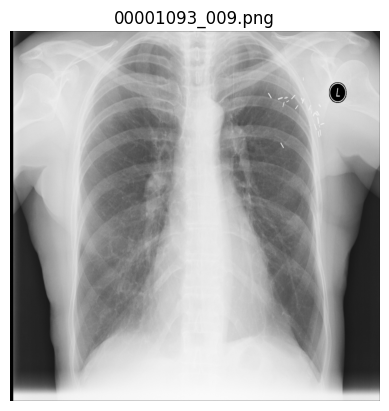

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

sample_img = os.listdir(IMG_DIR)[0]
img_path = os.path.join(IMG_DIR, sample_img)

img = Image.open(img_path)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title(sample_img)
plt.show()

In [ ]:
sample_img

'00001093_009.png'

In [ ]:
df[df["Image Index"] == sample_img][
    ["Image Index", "Finding Labels"]
]

,Image Index,Finding Labels
4021,00001093_009.png,No Finding


In [12]:
import os

image_files = os.listdir(IMG_DIR)

subset_df = df[df["Image Index"].isin(image_files)].copy()

subset_df["image_path"] = subset_df["Image Index"].apply(
    lambda x: os.path.join(IMG_DIR, x)
)

print("Images Found:", len(subset_df))
subset_df[["Image Index", "Finding Labels", "image_path"]].head()

Images Found: 4999


,Image Index,Finding Labels,image_path
0,00000001_000.png,Cardiomegaly,/content/drive/MyDrive/NIH_ChestXray/images_00...
1,00000001_001.png,Cardiomegaly|Emphysema,/content/drive/MyDrive/NIH_ChestXray/images_00...
2,00000001_002.png,Cardiomegaly|Effusion,/content/drive/MyDrive/NIH_ChestXray/images_00...
3,00000002_000.png,No Finding,/content/drive/MyDrive/NIH_ChestXray/images_00...
4,00000003_000.png,Hernia,/content/drive/MyDrive/NIH_ChestXray/images_00...


In [ ]:
subset_df["Finding Labels"].value_counts().head(20)

,count
Finding Labels,
No Finding,2754
Infiltration,417
Atelectasis,192
Effusion,156
Nodule,106
Fibrosis,94
Pneumothorax,90
Cardiomegaly,72
Consolidation,64


In [13]:
from sklearn.model_selection import train_test_split

# Keep only images from images_001
available_images = os.listdir(IMG_DIR)

subset_df = df[df["Image Index"].isin(available_images)].copy()

# Add image path
subset_df["image_path"] = subset_df["Image Index"].apply(
    lambda x: os.path.join(IMG_DIR, x)
)

# Split images_001 data into train and validation
train_subset, val_subset = train_test_split(
    subset_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train subset:", train_subset.shape)
print("Validation subset:", val_subset.shape)

Train subset: (3999, 27)
Validation subset: (1000, 27)


In [ ]:
train_subset[["Image Index", "Finding Labels", "image_path"]].head()

,Image Index,Finding Labels,image_path
1738,00000462_000.png,No Finding,/content/drive/MyDrive/NIH_ChestXray/images_00...
4943,00001320_000.png,Infiltration,/content/drive/MyDrive/NIH_ChestXray/images_00...
2916,00000772_006.png,No Finding,/content/drive/MyDrive/NIH_ChestXray/images_00...
1595,00000426_000.png,No Finding,/content/drive/MyDrive/NIH_ChestXray/images_00...
3214,00000847_001.png,No Finding,/content/drive/MyDrive/NIH_ChestXray/images_00...


In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# 14 disease labels
disease_labels = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, labels, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "image_path"]
        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            self.dataframe.loc[idx, self.labels].values.astype("float32")
        )

        return image, label

train_dataset = ChestXrayDataset(train_subset, disease_labels, transform)
val_dataset = ChestXrayDataset(val_subset, disease_labels, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 125
Validation batches: 32


In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 1, 224, 224])
Label batch shape: torch.Size([32, 14])


In [ ]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=14):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=14)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=14, bias=True)
  )
)


In [16]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Ready for training")

Ready for training


In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([32, 14])


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}"
    )

Epoch [1/5] Train Loss: 0.1904
Epoch [2/5] Train Loss: 0.1730
Epoch [3/5] Train Loss: 0.1708
Epoch [4/5] Train Loss: 0.1650
Epoch [5/5] Train Loss: 0.1574


In [ ]:
torch.save(model.state_dict(), "simple_cnn.pth")

print("Model Saved")

Model Saved


In [ ]:
model.eval()
val_loss = 0.0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()

val_loss = val_loss / len(val_loader)

print("Validation Loss:", round(val_loss, 4))

Validation Loss: 0.1849


In [ ]:
import torch

model.eval()

images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    probabilities = torch.sigmoid(outputs)

print(probabilities[0])
print(labels[0])

tensor([0.0532, 0.0488, 0.0326, 0.1304, 0.0593, 0.0451, 0.0048, 0.1162, 0.0054,
        0.0025, 0.0391, 0.0803, 0.0571, 0.0021], device='cuda:0')
tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import numpy as np

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

print("Predictions shape:", all_probs.shape)
print("Labels shape:", all_labels.shape)

Predictions shape: (1000, 14)
Labels shape: (1000, 14)


In [ ]:
# Convert probabilities to 0/1 using threshold 0.5
all_preds = (all_probs >= 0.5).astype(int)

micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

precision = precision_score(all_labels, all_preds, average="micro", zero_division=0)
recall = recall_score(all_labels, all_preds, average="micro", zero_division=0)

print("Micro F1:", round(micro_f1, 4))
print("Macro F1:", round(macro_f1, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))

Micro F1: 0.0136
Macro F1: 0.0057
Precision: 0.2778
Recall: 0.0069


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

aurocs = []

for i, disease in enumerate(disease_labels):

    if len(np.unique(all_labels[:, i])) > 1:

        auc = roc_auc_score(
            all_labels[:, i],
            all_probs[:, i]
        )

        aurocs.append(auc)

        print(f"{disease}: {auc:.4f}")

print("\nMean AUROC:", np.mean(aurocs))

Atelectasis: 0.6714
Cardiomegaly: 0.7847
Effusion: 0.7234
Infiltration: 0.6571
Mass: 0.6345
Nodule: 0.5277
Pneumonia: 0.5513
Pneumothorax: 0.6172
Consolidation: 0.7798
Edema: 0.9204
Emphysema: 0.6000
Fibrosis: 0.7091
Pleural_Thickening: 0.5021
Hernia: 0.7582

Mean AUROC: 0.6740625867707827


In [ ]:
import torchvision.models as models
import torch.nn as nn

resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Change first layer from 3-channel RGB to 1-channel grayscale
resnet18.conv1 = nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

# Change final layer to 14 disease outputs
resnet18.fc = nn.Linear(resnet18.fc.in_features, 14)

resnet18 = resnet18.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(resnet18.parameters(), lr=0.0001)

print("ResNet18 ready")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 78.9MB/s]


ResNet18 ready


In [ ]:
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = resnet18(images)

print(outputs.shape)

torch.Size([32, 14])


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    resnet18.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = resnet18(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}")

Epoch [1/5] Train Loss: 0.2774
Epoch [2/5] Train Loss: 0.1591
Epoch [3/5] Train Loss: 0.1373
Epoch [4/5] Train Loss: 0.1039
Epoch [5/5] Train Loss: 0.0633


In [ ]:
torch.save(resnet18.state_dict(), "resnet18_chestxray.pth")
print("ResNet18 Model Saved")

ResNet18 Model Saved


In [ ]:
resnet18.eval()

all_probs_resnet = []
all_labels_resnet = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = resnet18(images)
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_probs_resnet.append(probs)
        all_labels_resnet.append(labels.numpy())

all_probs_resnet = np.vstack(all_probs_resnet)
all_labels_resnet = np.vstack(all_labels_resnet)

print(all_probs_resnet.shape)
print(all_labels_resnet.shape)

(1000, 14)
(1000, 14)


In [ ]:
resnet_aurocs = []

for i, disease in enumerate(disease_labels):
    if len(np.unique(all_labels_resnet[:, i])) > 1:
        auc = roc_auc_score(all_labels_resnet[:, i], all_probs_resnet[:, i])
        resnet_aurocs.append(auc)
        print(f"{disease}: {auc:.4f}")

print("\nResNet18 Mean AUROC:", np.mean(resnet_aurocs))

Atelectasis: 0.6585
Cardiomegaly: 0.8544
Effusion: 0.8192
Infiltration: 0.6410
Mass: 0.7638
Nodule: 0.6057
Pneumonia: 0.5066
Pneumothorax: 0.8454
Consolidation: 0.8322
Edema: 0.8482
Emphysema: 0.7722
Fibrosis: 0.7112
Pleural_Thickening: 0.6111
Hernia: 0.8068

ResNet18 Mean AUROC: 0.7340193433932455


In [ ]:
torch.save(
    resnet18.state_dict(),
    "/content/drive/MyDrive/NIH_ChestXray/resnet18_chestxray.pth"
)

print("Saved to Google Drive")

Saved to Google Drive


In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 49.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=dab7308e49190c31a570e992eb276ff7de5a33ad9c1dbd3007dde3d117b3be8b
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
target_layers = [resnet18.layer4[-1]]

In [ ]:
sample_image, sample_label = val_dataset[0]

print(sample_image.shape)
print(sample_label)

torch.Size([1, 224, 224])
tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [ ]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

resnet18.eval()

# Prepare input image
input_tensor = sample_image.unsqueeze(0).to(device)

# Get prediction probabilities
with torch.no_grad():
    output = resnet18(input_tensor)
    probs = torch.sigmoid(output)[0]

# Get highest predicted disease index
target_category = torch.argmax(probs).item()

print("Predicted disease:", disease_labels[target_category])
print("Probability:", probs[target_category].item())

Predicted disease: Pneumothorax
Probability: 0.5622198581695557


In [ ]:
cam = GradCAM(
    model=resnet18,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(target_category)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0, :]

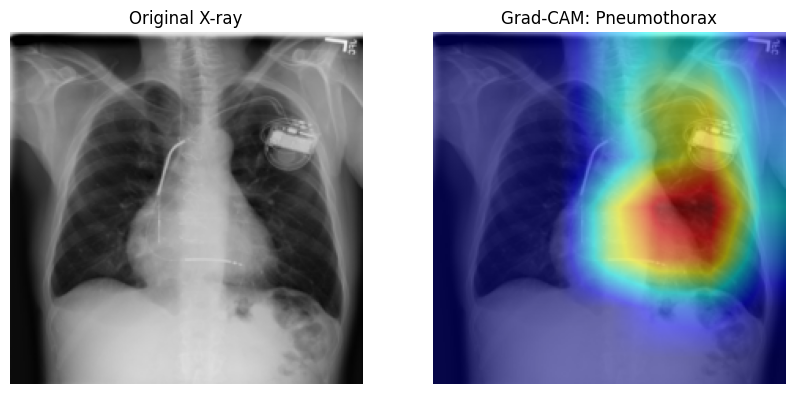

In [ ]:
# Convert grayscale tensor image to numpy
img_np = sample_image.squeeze().cpu().numpy()

# Undo normalization approximately
img_np = img_np * 0.229 + 0.485
img_np = np.clip(img_np, 0, 1)

# Convert 1-channel image to 3-channel
rgb_img = np.stack([img_np, img_np, img_np], axis=-1)

cam_image = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img, cmap="gray")
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title(f"Grad-CAM: {disease_labels[target_category]}")
plt.axis("off")

plt.show()

In [ ]:
disease_info = {
    "Atelectasis": "Collapse of part or all of a lung.",
    "Cardiomegaly": "Enlargement of the heart.",
    "Effusion": "Fluid accumulation around the lungs.",
    "Infiltration": "Substances such as fluid present in lung tissue.",
    "Mass": "Abnormal growth in the lung.",
    "Nodule": "Small abnormal tissue growth in the lung.",
    "Pneumonia": "Infection causing inflammation in the lungs.",
    "Pneumothorax": "Collapsed lung caused by air leakage.",
    "Consolidation": "Lung tissue filled with liquid instead of air.",
    "Edema": "Fluid accumulation in the lungs.",
    "Emphysema": "Damage to air sacs causing breathing difficulty.",
    "Fibrosis": "Scarring of lung tissue.",
    "Pleural_Thickening": "Thickening of the lung lining.",
    "Hernia": "Organ protrusion through surrounding tissue."
}

In [ ]:
predicted_disease = disease_labels[target_category]

print("Predicted Disease:", predicted_disease)
print("Explanation:", disease_info[predicted_disease])

Predicted Disease: Pneumothorax
Explanation: Collapsed lung caused by air leakage.


In [ ]:
probability = probs[target_category].item()

interpretation = f"""
AI-assisted Chest X-ray Interpretation

Predicted Finding:
{predicted_disease}

Model Confidence:
{probability:.2%}

Explanation:
{disease_info[predicted_disease]}

Grad-CAM Interpretation:
The heatmap highlights the image regions that contributed most strongly to the model prediction.

Disclaimer:
This output is generated by an AI model for educational and assistive purposes only. It is not a medical diagnosis. Final interpretation must be done by a qualified radiologist.
"""

print(interpretation)


AI-assisted Chest X-ray Interpretation

Predicted Finding:
Pneumothorax

Model Confidence:
56.22%

Explanation:
Collapsed lung caused by air leakage.

Grad-CAM Interpretation:
The heatmap highlights the image regions that contributed most strongly to the model prediction.

Disclaimer:
This output is generated by an AI model for educational and assistive purposes only. It is not a medical diagnosis. Final interpretation must be done by a qualified radiologist.



In [ ]:
knowledge_base = [
    {
        "id": "DOC1",
        "title": "Pneumothorax Definition",
        "text": "Pneumothorax refers to air in the pleural space, which can cause partial or complete lung collapse."
    },
    {
        "id": "DOC2",
        "title": "Cardiomegaly Definition",
        "text": "Cardiomegaly means enlargement of the heart, often visible on chest radiographs as an increased cardiac silhouette."
    },
    {
        "id": "DOC3",
        "title": "Dataset Limitation",
        "text": "NIH ChestX-ray14 labels were extracted using natural language processing from radiology reports, so label noise may exist."
    },
    {
        "id": "DOC4",
        "title": "Model Limitation",
        "text": "The AI model is assistive only and should not be used as a final medical diagnosis."
    },
    {
        "id": "DOC5",
        "title": "Grad-CAM",
        "text": "Grad-CAM highlights image regions that contributed most strongly to a CNN model prediction."
    }
]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

texts = [doc["text"] for doc in knowledge_base]

vectorizer = TfidfVectorizer()
doc_vectors = vectorizer.fit_transform(texts)

def retrieve_docs(query, top_k=3):
    query_vector = vectorizer.transform([query])
    similarities = cosine_similarity(query_vector, doc_vectors).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]
    return [knowledge_base[i] for i in top_indices]

query = f"{predicted_disease} model limitation Grad-CAM"
retrieved_docs = retrieve_docs(query)

for doc in retrieved_docs:
    print(doc["id"], "-", doc["title"])
    print(doc["text"])
    print()

DOC5 - Grad-CAM
Grad-CAM highlights image regions that contributed most strongly to a CNN model prediction.

DOC1 - Pneumothorax Definition
Pneumothorax refers to air in the pleural space, which can cause partial or complete lung collapse.

DOC4 - Model Limitation
The AI model is assistive only and should not be used as a final medical diagnosis.



In [ ]:
# Separate retrieved documents by type
disease_doc = next((doc for doc in retrieved_docs if predicted_disease in doc["title"] or predicted_disease in doc["text"]), None)
gradcam_doc = next((doc for doc in retrieved_docs if "Grad-CAM" in doc["title"]), None)
limitation_doc = next((doc for doc in retrieved_docs if "Limitation" in doc["title"]), None)

rag_summary = f"""
RAG-grounded AI Interpretation

Predicted Finding:
{predicted_disease}

Model Confidence:
{probability:.2%}

Retrieved Evidence:
[{disease_doc['id']}] {disease_doc['text']}
[{gradcam_doc['id']}] {gradcam_doc['text']}
[{limitation_doc['id']}] {limitation_doc['text']}

Interpretation:
The model predicts possible {predicted_disease}. Based on retrieved evidence, {disease_doc['text']}
The Grad-CAM heatmap provides visual support by highlighting regions that influenced the model prediction.

Disclaimer:
This is an AI-assisted educational output only. It is not a medical diagnosis. A qualified radiologist must make the final interpretation.
"""

print(rag_summary)


RAG-grounded AI Interpretation

Predicted Finding:
Pneumothorax

Model Confidence:
56.22%

Retrieved Evidence:
[DOC1] Pneumothorax refers to air in the pleural space, which can cause partial or complete lung collapse.
[DOC5] Grad-CAM highlights image regions that contributed most strongly to a CNN model prediction.
[DOC4] The AI model is assistive only and should not be used as a final medical diagnosis.

Interpretation:
The model predicts possible Pneumothorax. Based on retrieved evidence, Pneumothorax refers to air in the pleural space, which can cause partial or complete lung collapse.
The Grad-CAM heatmap provides visual support by highlighting regions that influenced the model prediction.

Disclaimer:
This is an AI-assisted educational output only. It is not a medical diagnosis. A qualified radiologist must make the final interpretation.



In [ ]:
from sklearn.metrics import average_precision_score

pr_aucs = []

for i, disease in enumerate(disease_labels):
    if len(np.unique(all_labels_resnet[:, i])) > 1:
        pr_auc = average_precision_score(all_labels_resnet[:, i], all_probs_resnet[:, i])
        pr_aucs.append(pr_auc)
        print(f"{disease}: {pr_auc:.4f}")

print("\nMean PR-AUC:", np.mean(pr_aucs))

Atelectasis: 0.1505
Cardiomegaly: 0.3274
Effusion: 0.3675
Infiltration: 0.3240
Mass: 0.1453
Nodule: 0.0680
Pneumonia: 0.0244
Pneumothorax: 0.3261
Consolidation: 0.2667
Edema: 0.1177
Emphysema: 0.2455
Fibrosis: 0.1424
Pleural_Thickening: 0.0974
Hernia: 0.0234

Mean PR-AUC: 0.18758122094445354


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Disease": disease_labels,
    "ResNet18_AUROC": resnet_aurocs,
    "ResNet18_PR_AUC": pr_aucs
})

results_df

,Disease,ResNet18_AUROC,ResNet18_PR_AUC
0,Atelectasis,0.658459,0.150467
1,Cardiomegaly,0.854366,0.327366
2,Effusion,0.819178,0.367468
3,Infiltration,0.641034,0.324045
4,Mass,0.763819,0.145318
5,Nodule,0.605729,0.067984
6,Pneumonia,0.506599,0.024366
7,Pneumothorax,0.845388,0.326073
8,Consolidation,0.832207,0.266702
9,Edema,0.848196,0.117684


In [ ]:
results_df.to_csv(
    "/content/drive/MyDrive/NIH_ChestXray/resnet18_results.csv",
    index=False
)

print("Results saved")

Results saved


In [ ]:
summary_df = pd.DataFrame({
    "Model": ["Simple CNN", "ResNet18"],
    "Mean AUROC": [0.6741, 0.7340],
    "Mean PR-AUC": ["Not calculated", 0.1876]
})

summary_df

,Model,Mean AUROC,Mean PR-AUC
0,Simple CNN,0.6741,Not calculated
1,ResNet18,0.7340,0.1876


In [ ]:
summary_df.to_csv(
    "/content/drive/MyDrive/NIH_ChestXray/model_comparison_summary.csv",
    index=False
)

print("Summary saved")

Summary saved


In [ ]:
import shutil

shutil.copy(
    "simple_cnn.pth",
    "/content/drive/MyDrive/NIH_ChestXray/simple_cnn.pth"
)

shutil.copy(
    "resnet18_chestxray.pth",
    "/content/drive/MyDrive/NIH_ChestXray/resnet18_chestxray.pth"
)

print("Models saved to Google Drive")

Models saved to Google Drive


In [ ]:
plt.savefig(
    "/content/drive/MyDrive/NIH_ChestXray/gradcam_example.png",
    bbox_inches="tight"
)

print("GradCAM saved")

GradCAM saved


<Figure size 640x480 with 0 Axes>

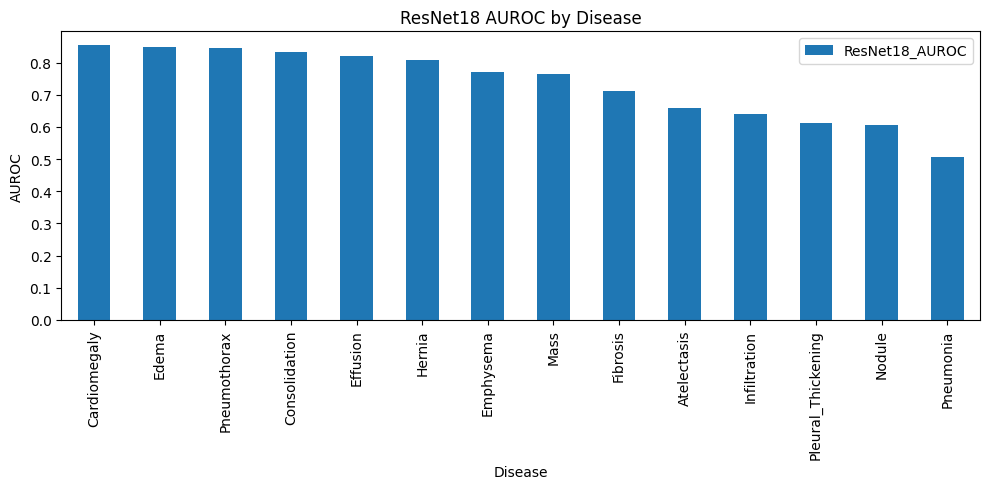

In [ ]:
import matplotlib.pyplot as plt

results_df.sort_values(
    "ResNet18_AUROC",
    ascending=False
).plot(
    x="Disease",
    y="ResNet18_AUROC",
    kind="bar",
    figsize=(10,5)
)

plt.title("ResNet18 AUROC by Disease")
plt.ylabel("AUROC")
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(
    "/content/drive/MyDrive/NIH_ChestXray/resnet18_auroc_chart.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [17]:
print("df:", df.shape)
print("train_dataset:", len(train_dataset))
print("val_dataset:", len(val_dataset))
print("labels:", len(disease_labels))
print("device:", device)

df: (112120, 26)
train_dataset: 3999
val_dataset: 1000
labels: 14
device: cuda


In [18]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

print("GPU memory cleared")

GPU memory cleared


In [19]:
from torch.utils.data import DataLoader

vgg_train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

vgg_val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("VGG Train batches:", len(vgg_train_loader))
print("VGG Validation batches:", len(vgg_val_loader))

VGG Train batches: 250
VGG Validation batches: 63


In [20]:
from torchvision import models
import torch.nn as nn

vgg19 = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

# Modify first convolution layer for grayscale X-ray images
vgg19.features[0] = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=3,
    stride=1,
    padding=1
)

# Modify final classifier layer for 14 disease labels
vgg19.classifier[6] = nn.Linear(
    vgg19.classifier[6].in_features,
    14
)

vgg19 = vgg19.to(device)

print("VGG19 ready")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 105MB/s]


VGG19 ready


In [21]:
images, labels = next(iter(vgg_train_loader))

images = images.to(device)

outputs = vgg19(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([16, 14])


In [22]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    vgg19.parameters(),
    lr=0.0001
)

num_epochs = 5

print("Ready for VGG19 training")

Ready for VGG19 training


In [23]:
for epoch in range(num_epochs):

    vgg19.train()

    running_loss = 0

    for images, labels in vgg_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = vgg19(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(vgg_train_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}"
    )

Epoch [1/5] Train Loss: 0.1878
Epoch [2/5] Train Loss: 0.1746
Epoch [3/5] Train Loss: 0.1713
Epoch [4/5] Train Loss: 0.1674
Epoch [5/5] Train Loss: 0.1635


In [24]:
torch.save(
    vgg19.state_dict(),
    "/content/drive/MyDrive/NIH_ChestXray/vgg19_chestxray.pth"
)

print("VGG19 model saved")

VGG19 model saved


In [25]:
import numpy as np

vgg19.eval()

all_probs_vgg = []
all_labels_vgg = []

with torch.no_grad():
    for images, labels in vgg_val_loader:
        images = images.to(device)

        outputs = vgg19(images)
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_probs_vgg.append(probs)
        all_labels_vgg.append(labels.numpy())

all_probs_vgg = np.vstack(all_probs_vgg)
all_labels_vgg = np.vstack(all_labels_vgg)

print("VGG predictions:", all_probs_vgg.shape)
print("VGG labels:", all_labels_vgg.shape)

VGG predictions: (1000, 14)
VGG labels: (1000, 14)


In [26]:
from sklearn.metrics import roc_auc_score
import numpy as np

vgg_aurocs = []

for i, disease in enumerate(disease_labels):
    if len(np.unique(all_labels_vgg[:, i])) > 1:
        auc = roc_auc_score(
            all_labels_vgg[:, i],
            all_probs_vgg[:, i]
        )
        vgg_aurocs.append(auc)
        print(f"{disease}: {auc:.4f}")

print("\nVGG19 Mean AUROC:", np.mean(vgg_aurocs))

Atelectasis: 0.6829
Cardiomegaly: 0.7282
Effusion: 0.7785
Infiltration: 0.6388
Mass: 0.5926
Nodule: 0.6211
Pneumonia: 0.4805
Pneumothorax: 0.6177
Consolidation: 0.8126
Edema: 0.8791
Emphysema: 0.5733
Fibrosis: 0.6971
Pleural_Thickening: 0.6924
Hernia: 0.5493

VGG19 Mean AUROC: 0.6674366363841859


In [27]:
from sklearn.metrics import average_precision_score

vgg_pr_aucs = []

for i, disease in enumerate(disease_labels):
    if len(np.unique(all_labels_vgg[:, i])) > 1:
        pr_auc = average_precision_score(
            all_labels_vgg[:, i],
            all_probs_vgg[:, i]
        )
        vgg_pr_aucs.append(pr_auc)
        print(f"{disease}: {pr_auc:.4f}")

print("\nVGG19 Mean PR-AUC:", np.mean(vgg_pr_aucs))

Atelectasis: 0.1740
Cardiomegaly: 0.2085
Effusion: 0.3034
Infiltration: 0.2950
Mass: 0.0504
Nodule: 0.0667
Pneumonia: 0.0270
Pneumothorax: 0.0798
Consolidation: 0.1115
Edema: 0.1199
Emphysema: 0.1059
Fibrosis: 0.0762
Pleural_Thickening: 0.0888
Hernia: 0.0121

VGG19 Mean PR-AUC: 0.12279010895258367


In [28]:
torch.save(
    vgg19.state_dict(),
    "/content/drive/MyDrive/NIH_ChestXray/vgg19_chestxray.pth"
)

print("VGG19 model saved")

VGG19 model saved


In [29]:
summary_df = pd.DataFrame({
    "Model": ["Simple CNN", "ResNet18", "VGG19"],
    "Mean AUROC": [0.6741, 0.7340, 0.6674],
    "Mean PR-AUC": ["Not calculated", 0.1876, 0.1228]
})

summary_df.to_csv(
    "/content/drive/MyDrive/NIH_ChestXray/model_comparison_summary.csv",
    index=False
)

summary_df

,Model,Mean AUROC,Mean PR-AUC
0,Simple CNN,0.6741,Not calculated
1,ResNet18,0.7340,0.1876
2,VGG19,0.6674,0.1228


In [30]:
torch.save(vgg19.state_dict(), "vgg19_chestxray.pth")

In [31]:
torch.save(
    vgg19.state_dict(),
    "/content/drive/MyDrive/NIH_ChestXray/vgg19_chestxray.pth"
)